# Partie 1 — Détection de Fake News (NLP)

**Projet :** Fake News Detection & AI Image Detection System  
**Bibliothèques :** scikit-learn · pandas · numpy · nltk · matplotlib · seaborn

---

## Plan de cette partie

| Étape | Description |
|-------|-------------|
| 1 | Installation & imports |
| 2 | Chargement et exploration du dataset |
| 3 | Prétraitement du texte |
| 4 | Extraction de features (TF-IDF) |
| 5 | Entraînement de 3 modèles (LR, NB, SVM) |
| 6 | Évaluation complète |
| 7 | Sauvegarde du meilleur modèle |
| 8 | Démo d'inférence |

---

## Dataset requis

Télécharge le dataset depuis Kaggle :  
https://www.kaggle.com/datasets/clmentbisaillon/fake-and-real-news-dataset

Place les fichiers `Fake.csv` et `True.csv` dans un dossier `data/` au même niveau que ce notebook.

---
## Étape 1 — Installation des bibliothèques

In [1]:
# Lance cette cellule une seule fois pour installer les dépendances
import sys
!{sys.executable} -m pip install pandas numpy scikit-learn nltk matplotlib seaborn joblib --quiet
print('Installation terminee')

Installation terminee


In [2]:
# ── Imports standard ──────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import re
import string
import os
import warnings
warnings.filterwarnings('ignore')

# ── Visualisation ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
sns.set_theme(style='whitegrid', palette='muted')
%matplotlib inline

# ── NLP ───────────────────────────────────────────────────────────────────────
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# ── Scikit-learn ──────────────────────────────────────────────────────────────
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
import joblib

# ── Téléchargement des ressources NLTK (une seule fois) ───────────────────────
nltk.download('stopwords', quiet=True)
nltk.download('wordnet',   quiet=True)
nltk.download('omw-1.4',   quiet=True)

print('Tous les imports sont prets !')

Tous les imports sont prets !


---
## Étape 2 — Chargement et exploration du dataset

Le dataset contient deux fichiers :
- **`Fake.csv`** : articles de fake news (label = 0)
- **`True.csv`** : vrais articles de presse (label = 1)

In [4]:
# ── Chargement des CSV ────────────────────────────────────────────────────────
# Assure-toi que Fake.csv et True.csv sont dans le dossier data/
DATA_PATH = 'data/'

fake_df = pd.read_csv(DATA_PATH + 'Fake.csv')
real_df = pd.read_csv(DATA_PATH + 'True.csv')

# ── Ajout des labels ──────────────────────────────────────────────────────────
fake_df['label'] = 0   # 0 = FAKE
real_df['label'] = 1   # 1 = REAL

# ── Fusion des deux dataframes ────────────────────────────────────────────────
df = pd.concat([fake_df, real_df], ignore_index=True)

# ── Mélange aléatoire des lignes ──────────────────────────────────────────────
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f'Total articles  : {len(df):,}')
print(f'Fake articles   : {len(fake_df):,}')
print(f'Real articles   : {len(real_df):,}')
print(f'\nColonnes : {df.columns.tolist()}')
df.head(3)

Total articles  : 44,898
Fake articles   : 23,481
Real articles   : 21,417

Colonnes : ['title', 'text', 'subject', 'date', 'label']


,title,text,subject,date,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",0
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",1
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",1


Valeurs manquantes par colonne :
title      0
text       0
subject    0
date       0
label      0
dtype: int64


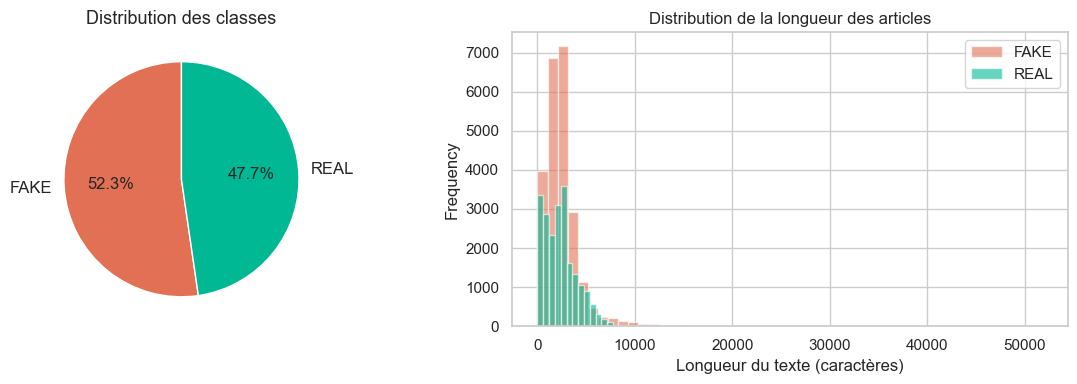

In [5]:
# ── Vérification des valeurs manquantes ───────────────────────────────────────
print('Valeurs manquantes par colonne :')
print(df.isnull().sum())

# ── Visualisation de la distribution des classes ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Graphe 1 : pie chart
counts = df['label'].value_counts()
axes[0].pie(
    counts,
    labels=['FAKE', 'REAL'],
    colors=['#E17055', '#00B894'],
    autopct='%1.1f%%',
    startangle=90,
    textprops={'fontsize': 12}
)
axes[0].set_title('Distribution des classes', fontsize=13)

# Graphe 2 : longueur des articles
df['text_length'] = df['text'].fillna('').apply(len)
for label_val, color, name in [(0, '#E17055', 'FAKE'), (1, '#00B894', 'REAL')]:
    df[df['label'] == label_val]['text_length'].plot(
        kind='hist', bins=50, alpha=0.6, ax=axes[1],
        color=color, label=name
    )
axes[1].set_xlabel('Longueur du texte (caractères)')
axes[1].set_title('Distribution de la longueur des articles')
axes[1].legend()

plt.tight_layout()
plt.show()

---
## Étape 3 — Prétraitement du texte

Pipeline de nettoyage appliqué à chaque article :

```
Texte brut
  → minuscules
  → suppression des URLs
  → suppression ponctuation & chiffres
  → tokenisation (découpe en mots)
  → suppression des stopwords (the, is, at...)
  → lemmatisation (running → run, better → good)
  → texte propre
```

**Lemmatisation vs Stemming :**
- Stemming : coupe brutalement (`running` → `runn`) — rapide mais imprécis
- Lemmatisation : utilise un dictionnaire (`running` → `run`) — plus lent mais correct

In [6]:
# ── Initialisation des outils NLP ─────────────────────────────────────────────
lemmatizer = WordNetLemmatizer()
stop_words  = set(stopwords.words('english'))

def preprocess_text(text):
    """
    Nettoie et normalise un article de presse.

    Étapes :
      1. Minuscules
      2. Suppression des URLs
      3. Suppression ponctuation et chiffres
      4. Tokenisation
      5. Suppression stopwords et mots trop courts
      6. Lemmatisation
      7. Rejoindre en une chaîne
    """
    if not isinstance(text, str):
        return ''

    # 1. Minuscules
    text = text.lower()

    # 2. Supprimer les URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # 3. Supprimer la ponctuation et les chiffres
    text = re.sub(r'[%s]' % re.escape(string.punctuation), ' ', text)
    text = re.sub(r'\d+', '', text)

    # 4. Tokeniser
    tokens = text.split()

    # 5. Supprimer stopwords et mots courts (moins de 3 caractères)
    tokens = [w for w in tokens if w not in stop_words and len(w) > 2]

    # 6. Lemmatiser
    tokens = [lemmatizer.lemmatize(w) for w in tokens]

    # 7. Rejoindre
    return ' '.join(tokens)


# ── Démonstration avant / après ───────────────────────────────────────────────
sample = df['text'].iloc[0]
print('AVANT nettoyage :')
print(sample[:300])
print('\nAPRES nettoyage :')
print(preprocess_text(sample)[:300])

AVANT nettoyage :
21st Century Wire says Ben Stein, reputable professor from, Pepperdine University (also of some Hollywood fame appearing in TV shows and films such as Ferris Bueller s Day Off) made some provocative statements on Judge Jeanine Pirro s show recently. While discussing the halt that was imposed on Pres

APRES nettoyage :
century wire say ben stein reputable professor pepperdine university also hollywood fame appearing show film ferris bueller day made provocative statement judge jeanine pirro show recently discussing halt imposed president trump executive order travel stein referred judgement circuit court washingto


In [7]:
# ── Combiner titre + texte pour plus de signal ────────────────────────────────
# Les titres des fake news sont souvent très révélateurs
df['content'] = df['title'].fillna('') + ' ' + df['text'].fillna('')

# ── Appliquer le prétraitement à tous les articles ────────────────────────────
# Cela peut prendre 1 à 2 minutes selon ton ordinateur
print('Pretraitement en cours... (1-2 minutes)')
df['clean_content'] = df['content'].apply(preprocess_text)
print(f'Pretraitement termine ! {len(df):,} articles traites.')

# ── Supprimer les lignes vides après nettoyage ────────────────────────────────
df = df[df['clean_content'].str.len() > 10].reset_index(drop=True)
print(f'Articles conserves apres filtrage : {len(df):,}')

Pretraitement en cours... (1-2 minutes)
Pretraitement termine ! 44,898 articles traites.
Articles conserves apres filtrage : 44,889


---
## Étape 4 — Extraction de features avec TF-IDF

### Qu'est-ce que TF-IDF ?

**TF (Term Frequency)** = fréquence d'un mot dans un article spécifique  
**IDF (Inverse Document Frequency)** = rareté du mot dans tout le corpus  
**TF-IDF = TF × IDF** : un mot fréquent dans un article mais rare globalement → score élevé

Exemple :
- Le mot `the` apparaît partout → IDF très bas → TF-IDF ≈ 0 (pas utile)
- Le mot `hoax` est rare → IDF élevé → si présent dans un article → TF-IDF élevé (très utile)

**Paramètres utilisés :**
- `max_features=50000` : garde les 50 000 termes les plus importants
- `ngram_range=(1,2)` : capture aussi les bigrammes ("fake news", "white house")
- `sublinear_tf=True` : utilise log(1 + tf) pour atténuer les répétitions excessives

In [8]:
# ── Préparation X (features) et y (labels) ────────────────────────────────────
X = df['clean_content']
y = df['label']

# ── Split train / test : 80% / 20% ───────────────────────────────────────────
# stratify=y garantit la même proportion FAKE/REAL dans chaque split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Donnees d'entrainement : {len(X_train):,} articles")
print(f'Donnees de test        : {len(X_test):,} articles')
print(f'Distribution (train)   : {dict(y_train.value_counts())}')

Donnees d'entrainement : 35,911 articles
Donnees de test        : 8,978 articles
Distribution (train)   : {0: np.int64(18777), 1: np.int64(17134)}


In [9]:
# ── Création du vectoriseur TF-IDF ────────────────────────────────────────────
tfidf = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 2),
    sublinear_tf=True,
    min_df=2
)

# IMPORTANT : fit UNIQUEMENT sur les données d'entraînement
# Si on fittait sur tout le dataset, le modèle "verrait" les données de test
# avant l'évaluation → biais (data leakage)
X_train_tfidf = tfidf.fit_transform(X_train)   # fit + transform
X_test_tfidf  = tfidf.transform(X_test)        # transform seulement

print(f'Matrice features (train) : {X_train_tfidf.shape}')
print(f'  => {X_train_tfidf.shape[0]:,} articles x {X_train_tfidf.shape[1]:,} features')
print(f'\nExemples de features : {list(tfidf.get_feature_names_out()[:8])}')

Matrice features (train) : (35911, 50000)
  => 35,911 articles x 50,000 features

Exemples de features : ['aadhaar', 'aapl', 'aaron', 'aba', 'ababa', 'aback', 'abadi', 'abadi said']


---
## Étape 5 — Entraînement des 3 modèles

| Modèle | Principe | Avantage |
|--------|----------|----------|
| **Logistic Regression** | Frontière de décision linéaire dans l'espace TF-IDF | Rapide, interprétable |
| **Naive Bayes** | Probabilités bayésiennes (hypothèse d'indépendance) | Très rapide, bon baseline |
| **LinearSVC** | SVM linéaire — maximise la marge entre les classes | Souvent le plus précis en NLP |

In [10]:
# ── Définition des modèles avec leurs hyperparamètres ────────────────────────
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000,    # nombre max d'itérations pour la convergence
        C=1.0,            # régularisation (plus petit = plus régularisé)
        solver='lbfgs',
        n_jobs=-1         # utiliser tous les coeurs CPU
    ),
    'Naive Bayes': MultinomialNB(
        alpha=0.1         # lissage de Laplace (évite les probabilités nulles)
    ),
    'SVM (LinearSVC)': LinearSVC(
        C=1.0,
        max_iter=2000
    )
}

# ── Entraînement et collecte des résultats ────────────────────────────────────
results = {}

for name, model in models.items():
    print(f'\nEntrainement : {name}')

    model.fit(X_train_tfidf, y_train)
    y_pred  = model.predict(X_test_tfidf)
    acc     = accuracy_score(y_test, y_pred)
    report  = classification_report(y_test, y_pred,
                                    target_names=['FAKE', 'REAL'],
                                    output_dict=True)
    cm_val  = confusion_matrix(y_test, y_pred)

    results[name] = {
        'model'   : model,
        'y_pred'  : y_pred,
        'accuracy': acc,
        'report'  : report,
        'cm'      : cm_val
    }

    print(f'  Accuracy  : {acc*100:.2f}%')
    print(f'  Precision : {report["weighted avg"]["precision"]:.4f}')
    print(f'  Recall    : {report["weighted avg"]["recall"]:.4f}')
    print(f'  F1-Score  : {report["weighted avg"]["f1-score"]:.4f}')

print('\nEntrainement termine !')


Entrainement : Logistic Regression
  Accuracy  : 99.24%
  Precision : 0.9925
  Recall    : 0.9924
  F1-Score  : 0.9924

Entrainement : Naive Bayes
  Accuracy  : 96.78%
  Precision : 0.9678
  Recall    : 0.9678
  F1-Score  : 0.9678

Entrainement : SVM (LinearSVC)
  Accuracy  : 99.80%
  Precision : 0.9980
  Recall    : 0.9980
  F1-Score  : 0.9980

Entrainement termine !


---
## Étape 6 — Évaluation complète

**Métriques expliquées :**
- **Accuracy** : pourcentage de bonnes prédictions globales
- **Precision** : parmi les articles classés FAKE, combien sont vraiment FAKE ?
- **Recall** : parmi les vrais FAKE, combien ont été détectés ?
- **F1-Score** : moyenne harmonique de precision et recall (meilleure métrique globale si classes déséquilibrées)

In [11]:
# ── Rapport détaillé pour chaque modèle ──────────────────────────────────────
for name, res in results.items():
    print(f'\n{"="*55}')
    print(f'  Modele : {name}')
    print(f'{"="*55}')
    print(classification_report(
        y_test, res['y_pred'],
        target_names=['FAKE', 'REAL']
    ))


  Modele : Logistic Regression
              precision    recall  f1-score   support

        FAKE       1.00      0.99      0.99      4695
        REAL       0.99      1.00      0.99      4283

    accuracy                           0.99      8978
   macro avg       0.99      0.99      0.99      8978
weighted avg       0.99      0.99      0.99      8978


  Modele : Naive Bayes
              precision    recall  f1-score   support

        FAKE       0.97      0.97      0.97      4695
        REAL       0.96      0.97      0.97      4283

    accuracy                           0.97      8978
   macro avg       0.97      0.97      0.97      8978
weighted avg       0.97      0.97      0.97      8978


  Modele : SVM (LinearSVC)
              precision    recall  f1-score   support

        FAKE       1.00      1.00      1.00      4695
        REAL       1.00      1.00      1.00      4283

    accuracy                           1.00      8978
   macro avg       1.00      1.00      1.00 

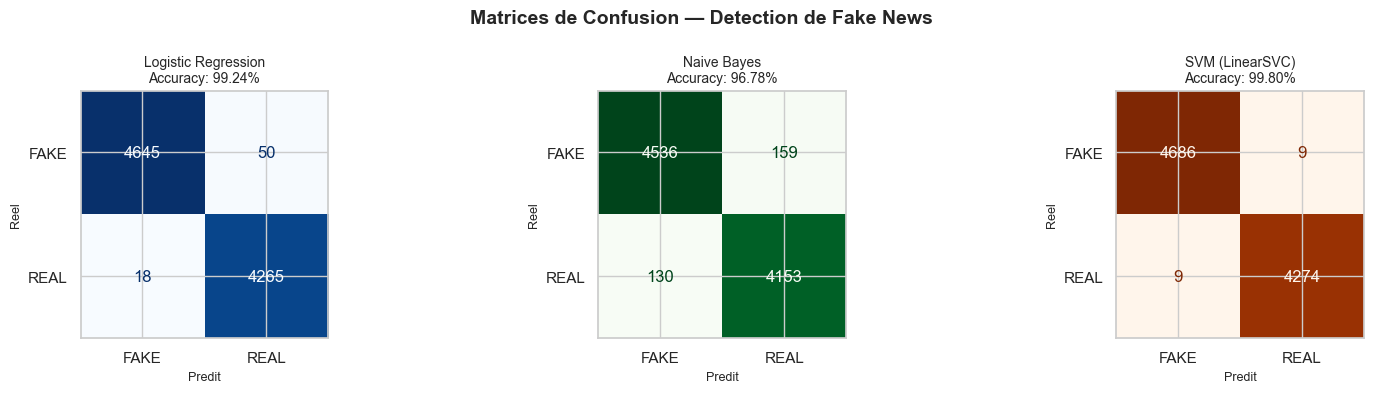

Sauvegarde : outputs/confusion_matrices.png


In [12]:
# ── Matrices de confusion ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Matrices de Confusion — Detection de Fake News',
             fontsize=14, fontweight='bold')

for ax, (name, res), cmap in zip(axes, results.items(), ['Blues', 'Greens', 'Oranges']):
    disp = ConfusionMatrixDisplay(
        confusion_matrix=res['cm'],
        display_labels=['FAKE', 'REAL']
    )
    disp.plot(ax=ax, colorbar=False, cmap=cmap)
    ax.set_title(f"{name}\nAccuracy: {res['accuracy']*100:.2f}%", fontsize=10)
    ax.set_xlabel('Predit', fontsize=9)
    ax.set_ylabel('Reel', fontsize=9)

plt.tight_layout()
os.makedirs('outputs', exist_ok=True)
plt.savefig('outputs/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('Sauvegarde : outputs/confusion_matrices.png')

             Modele Accuracy Precision Recall F1-Score
Logistic Regression   99.24%    99.25% 99.24%   99.24%
        Naive Bayes   96.78%    96.78% 96.78%   96.78%
    SVM (LinearSVC)   99.80%    99.80% 99.80%   99.80%


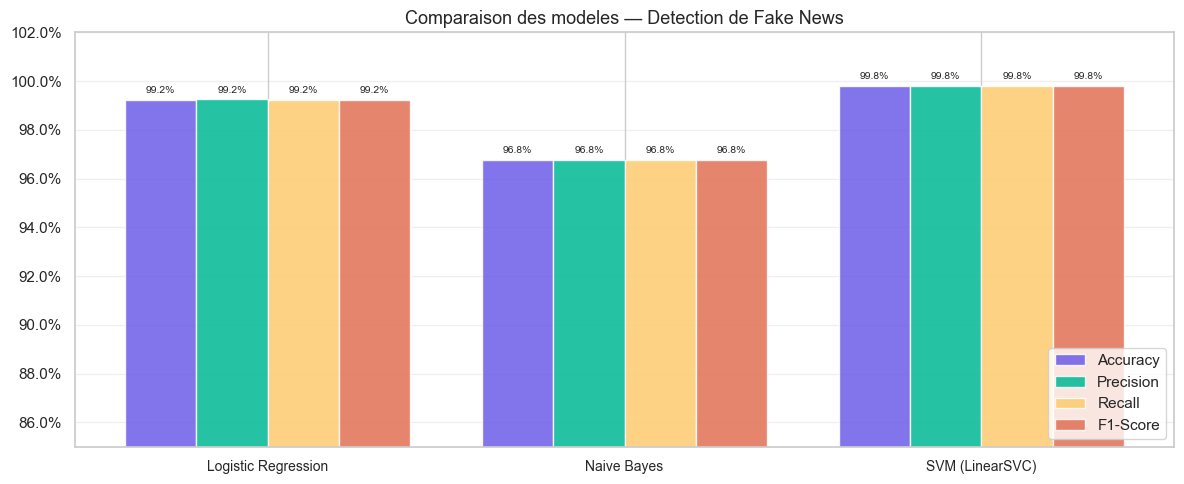

Sauvegarde : outputs/model_comparison.png


In [13]:
# ── Graphique comparatif des 4 métriques pour les 3 modèles ──────────────────
metrics_data = []
for name, res in results.items():
    r = res['report']
    metrics_data.append({
        'Modele'   : name,
        'Accuracy' : res['accuracy'],
        'Precision': r['weighted avg']['precision'],
        'Recall'   : r['weighted avg']['recall'],
        'F1-Score' : r['weighted avg']['f1-score']
    })

metrics_df = pd.DataFrame(metrics_data)

# Tableau récapitulatif
display_df = metrics_df.copy()
for col in ['Accuracy', 'Precision', 'Recall', 'F1-Score']:
    display_df[col] = display_df[col].apply(lambda x: f'{x*100:.2f}%')
print(display_df.to_string(index=False))

# Graphique barres groupées
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(metrics_df))
width = 0.2
metric_cols  = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors_bar   = ['#6C5CE7', '#00B894', '#FDCB6E', '#E17055']

for i, (metric, color) in enumerate(zip(metric_cols, colors_bar)):
    bars = ax.bar(x + i*width, metrics_df[metric], width,
                  label=metric, color=color, alpha=0.85)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.002,
                f'{bar.get_height()*100:.1f}%',
                ha='center', va='bottom', fontsize=7.5)

ax.set_xticks(x + width*1.5)
ax.set_xticklabels(metrics_df['Modele'], fontsize=10)
ax.set_ylim(0.85, 1.02)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_title('Comparaison des modeles — Detection de Fake News', fontsize=13)
ax.legend(loc='lower right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('outputs/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Sauvegarde : outputs/model_comparison.png')

---
## Étape 7 — Sauvegarde du meilleur modèle

On sauvegarde deux fichiers :
1. **`best_classifier.pkl`** — le modèle entraîné
2. **`tfidf_vectorizer.pkl`** — le vectoriseur TF-IDF

Les deux sont nécessaires à l'inférence : sans le vectoriseur, on ne peut pas transformer un nouveau texte de la même façon.

In [14]:
# ── Identifier le meilleur modèle ─────────────────────────────────────────────
best_name  = max(results, key=lambda n: results[n]['accuracy'])
best_model = results[best_name]['model']
best_acc   = results[best_name]['accuracy']

print(f'Meilleur modele : {best_name}')
print(f'Accuracy        : {best_acc*100:.2f}%')

# ── Sauvegarder avec joblib ───────────────────────────────────────────────────
os.makedirs('models', exist_ok=True)
joblib.dump(best_model, 'models/best_classifier.pkl')
joblib.dump(tfidf,      'models/tfidf_vectorizer.pkl')

print('\nFichiers sauvegardes :')
print('  models/best_classifier.pkl')
print('  models/tfidf_vectorizer.pkl')

Meilleur modele : SVM (LinearSVC)
Accuracy        : 99.80%

Fichiers sauvegardes :
  models/best_classifier.pkl
  models/tfidf_vectorizer.pkl


---
## Étape 8 — Démo d'inférence

On recharge le modèle depuis le disque (comme le fera l'application web) et on teste sur des exemples réels.

In [15]:
# ── Rechargement depuis le disque ─────────────────────────────────────────────
loaded_model      = joblib.load('models/best_classifier.pkl')
loaded_vectorizer = joblib.load('models/tfidf_vectorizer.pkl')

def predict_news(text):
    """
    Prédit si un article est FAKE ou REAL.
    Retourne un dict avec 'label' et 'confidence'.
    """
    cleaned  = preprocess_text(text)
    features = loaded_vectorizer.transform([cleaned])
    pred     = loaded_model.predict(features)[0]
    label    = 'REAL' if pred == 1 else 'FAKE'

    try:
        proba      = loaded_model.predict_proba(features)[0]
        confidence = max(proba) * 100
    except AttributeError:
        # LinearSVC n'a pas predict_proba : on utilise decision_function
        score      = loaded_model.decision_function(features)[0]
        confidence = min(abs(float(score)) * 25, 99.9)

    return {'label': label, 'confidence': round(confidence, 1)}


# ── Articles de test ──────────────────────────────────────────────────────────
test_articles = [
    {
        'titre': 'Fake news evidente',
        'texte': 'Scientists have discovered that drinking bleach cures all diseases. The government is hiding this cure to keep pharmaceutical companies rich.'
    },
    {
        'titre': 'Vrai article economique',
        'texte': 'The Federal Reserve raised interest rates by 25 basis points on Wednesday following its latest two-day policy meeting, as expected by Wall Street analysts.'
    },
    {
        'titre': 'Fake news complotiste',
        'texte': 'BREAKING: The president was secretly replaced by a robot in 2020. Anonymous sources inside the White House confirm this shocking global conspiracy.'
    },
    {
        'titre': 'Vrai article scientifique',
        'texte': 'Researchers at MIT have published new findings on quantum computing, demonstrating a 1000-qubit processor capable of solving optimization problems significantly faster than classical computers.'
    }
]

print(f'Modele utilise : {best_name}\n')
print(f'{"─"*65}')

for article in test_articles:
    result = predict_news(article['texte'])
    emoji  = 'OK' if result['label'] == 'REAL' else 'XX'
    print(f"\n[{emoji}] {article['titre']}")
    print(f"  Texte      : {article['texte'][:80]}...")
    print(f"  Prediction : {result['label']}  |  Confiance : {result['confidence']}%")

print(f'\n{"─"*65}')
print('PARTIE 1 COMPLETE — Modele pret pour l application web !')

Modele utilise : SVM (LinearSVC)

─────────────────────────────────────────────────────────────────

[XX] Fake news evidente
  Texte      : Scientists have discovered that drinking bleach cures all diseases. The governme...
  Prediction : FAKE  |  Confiance : 10.2%

[XX] Vrai article economique
  Texte      : The Federal Reserve raised interest rates by 25 basis points on Wednesday follow...
  Prediction : FAKE  |  Confiance : 0.9%

[XX] Fake news complotiste
  Texte      : BREAKING: The president was secretly replaced by a robot in 2020. Anonymous sour...
  Prediction : FAKE  |  Confiance : 30.6%

[XX] Vrai article scientifique
  Texte      : Researchers at MIT have published new findings on quantum computing, demonstrati...
  Prediction : FAKE  |  Confiance : 12.2%

─────────────────────────────────────────────────────────────────
PARTIE 1 COMPLETE — Modele pret pour l application web !


In [16]:
# ── Résumé final ──────────────────────────────────────────────────────────────
print('=' * 55)
print('   RESUME — PARTIE 1 : FAKE NEWS DETECTION')
print('=' * 55)
print(f'  Dataset   : {len(df):,} articles (FAKE + REAL)')
print(f'  Features  : TF-IDF unigrammes + bigrammes (50 000)')
print(f'  Modeles   : Logistic Regression, Naive Bayes, SVM')
print()
for name, res in results.items():
    marker = '  <-- MEILLEUR' if name == best_name else ''
    print(f'  {name:25s} : {res["accuracy"]*100:.2f}%{marker}')
print()
print('  Fichiers sauvegardes :')
print('    models/best_classifier.pkl')
print('    models/tfidf_vectorizer.pkl')
print('=' * 55)

   RESUME — PARTIE 1 : FAKE NEWS DETECTION
  Dataset   : 44,889 articles (FAKE + REAL)
  Features  : TF-IDF unigrammes + bigrammes (50 000)
  Modeles   : Logistic Regression, Naive Bayes, SVM

  Logistic Regression       : 99.24%
  Naive Bayes               : 96.78%
  SVM (LinearSVC)           : 99.80%  <-- MEILLEUR

  Fichiers sauvegardes :
    models/best_classifier.pkl
    models/tfidf_vectorizer.pkl


---
## Partie 1 terminee !

**Ce qu'on a accompli :**
- Chargé et exploré le dataset Kaggle Fake News (44 000+ articles)
- Nettoyé le texte : lowercase, URLs, ponctuation, stopwords, lemmatisation
- Extrait les features avec TF-IDF (50 000 features, bigrammes)
- Entraîné 3 modèles : Logistic Regression, Naive Bayes, SVM
- Évalué : accuracy, precision, recall, F1, matrices de confusion
- Sauvegardé le meilleur modèle et le vectoriseur
- Testé l'inférence sur des exemples réels

---
**Prochaine étape : Partie 2 — Détection d'images IA avec CNN (TensorFlow/Keras)**